In [1]:
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import torch
import torch.nn as nn
import numpy as np
import os
from PIL import Image, ImageDraw
import zarr
from tqdm.notebook import tqdm
import json
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.filters import frangi , hessian , meijering
from pathlib import Path
import cv2
import segmentation_models_pytorch as smp
from torchview import draw_graph

Main output: torch.Size([2, 2, 448, 448])
Deep supervision outputs:
  x_0_0: torch.Size([2, 2, 448, 448])
  x_1_1: torch.Size([2, 2, 448, 448])
  x_2_2: torch.Size([2, 2, 448, 448])
  x_3_3: torch.Size([2, 2, 448, 448])
  x_0_1: torch.Size([2, 2, 448, 448])
  x_1_2: torch.Size([2, 2, 448, 448])
  x_2_3: torch.Size([2, 2, 448, 448])
  x_0_2: torch.Size([2, 2, 448, 448])
  x_1_3: torch.Size([2, 2, 448, 448])
  x_0_3: torch.Size([2, 2, 448, 448])
  x_0_4: torch.Size([2, 2, 448, 448])


In [12]:
main_out.shape

torch.Size([2, 2, 448, 448])

In [2]:
class UNetPlusPlusDeepSupervision(nn.Module):
    def __init__(self, encoder_name="resnet50", encoder_weights="imagenet",
                 in_channels=3, classes=2):
        super().__init__()

        # Base SMP model
        self.model = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes
        )

        self.encoder = self.model.encoder
        self.decoder = self.model.decoder

        # Same type of segmentation head
        SegHead = type(self.model.segmentation_head)
        ch = self.decoder.out_channels

        self.head4 = SegHead(ch[0], classes, 1)
        self.head3 = SegHead(ch[1], classes, 1)
        self.head2 = SegHead(ch[2], classes, 1)
        self.head1 = SegHead(ch[3], classes, 1)

    def forward(self, x):
        # ========== 1. Encoder ==========
        feats = self.encoder(x)
        # feats = [x_0_0, x_1_0, x_2_0, x_3_0, x_4_0]

        x_0_0, x_1_0, x_2_0, x_3_0, x_4_0 = feats

        dec = self.decoder

        # ========== 2. Manually run decoder blocks ==========

        # row 1
        x_0_1 = dec.blocks[0][0](x_0_0, x_1_0)
        x_1_1 = dec.blocks[1][0](x_1_0, x_2_0)
        x_2_1 = dec.blocks[2][0](x_2_0, x_3_0)
        x_3_1 = dec.blocks[3][0](x_3_0, x_4_0)

        # row 2
        x_0_2 = dec.blocks[0][1](x_0_0, x_0_1, x_1_1)
        x_1_2 = dec.blocks[1][1](x_1_0, x_1_1, x_2_1)
        x_2_2 = dec.blocks[2][1](x_2_0, x_2_1, x_3_1)

        # row 3
        x_0_3 = dec.blocks[0][2](x_0_0, x_0_1, x_0_2, x_1_2)
        x_1_3 = dec.blocks[1][2](x_1_0, x_1_1, x_1_2, x_2_2)

        # row 4 (final)
        x_0_4 = dec.blocks[0][3](x_0_0, x_0_1, x_0_2, x_0_3, x_1_3)

        # ========== 3. Deep supervision heads ==========
        o4 = self.head4(x_0_4)  # coarse
        o3 = self.head3(x_0_3)
        o2 = self.head2(x_0_2)
        o1 = self.head1(x_0_1)  # finest deep-supervision level

        return [o4, o3, o2, o1]  # lowest → highest resolution


In [4]:
model = UNetPlusPlusDeepSupervision()
res = model(torch.rand(2,3,448,448))

ValueError: too many values to unpack (expected 5)

In [7]:
model = UnetP()
model_graph = draw_graph(
    model,
    input_size=(1, 3, 448, 448),   # or input_data=torch.randn(1, 3, 32, 32)
    expand_nested=True,          # show layers inside nn.Sequential etc.
    graph_name="simple_cnn",
)
model_graph.visual_graph.render("simple_cnn", format="png") 

'simple_cnn.png'

In [8]:
model

UnetP(
  (model): UnetPlusPlus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(

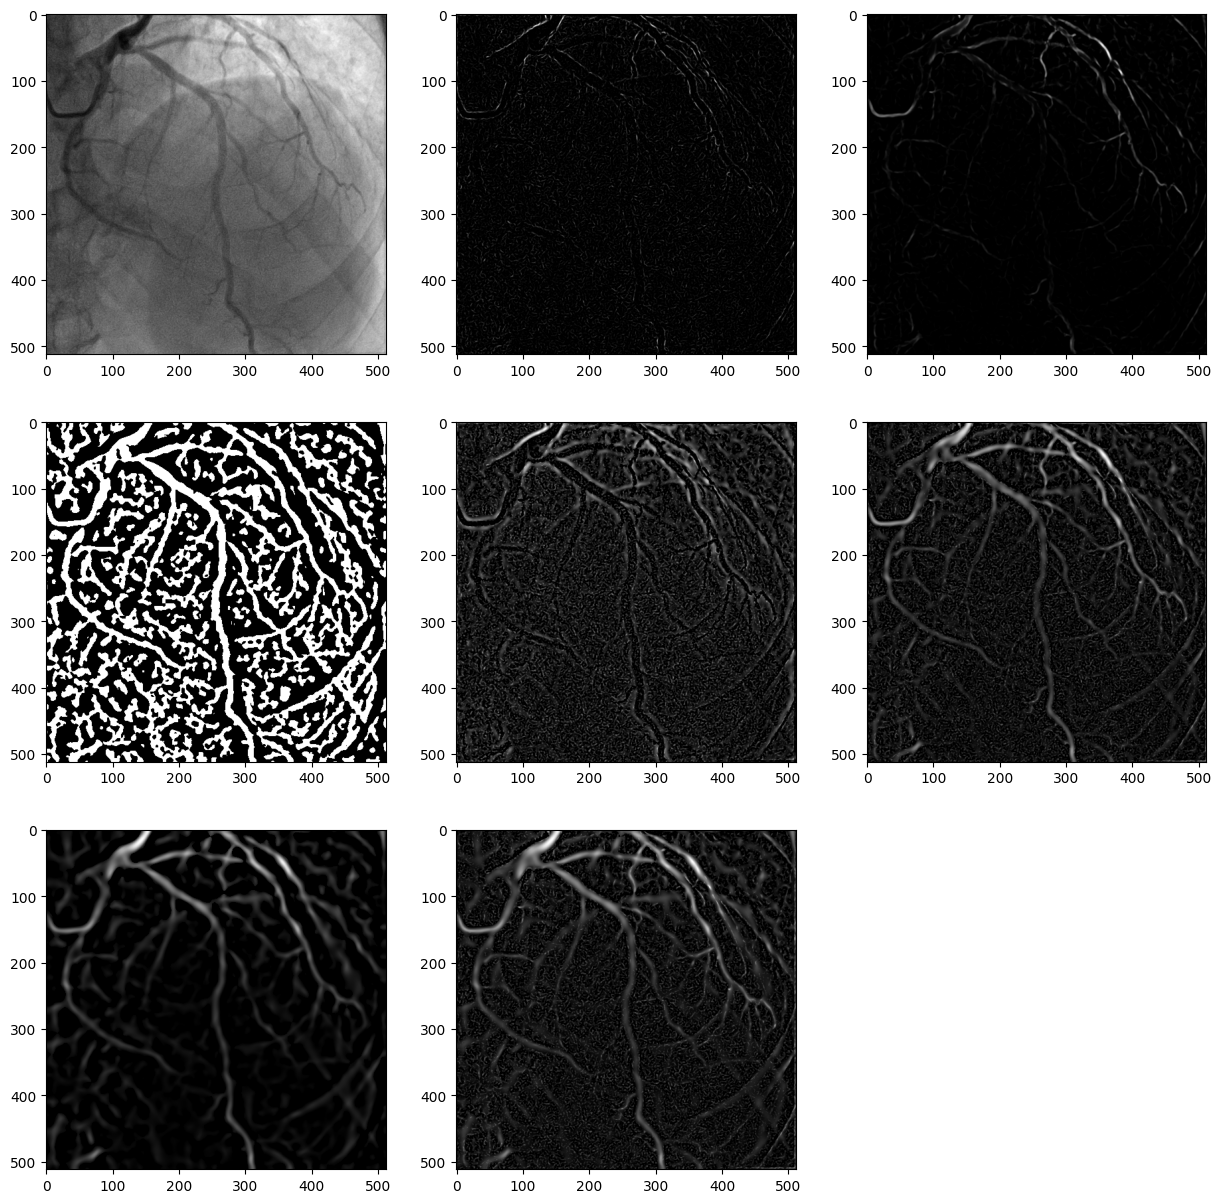

In [2]:
img_path = "../dataset/syntax/images/train/6.png"

img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
f_img1 = frangi(img,sigmas = range(1, 10, 2),black_ridges=False)
f_img2 = frangi(img,sigmas = [2,3,4,5,6])
hess1 = hessian(img,sigmas=[3,4,5],black_ridges=False)
mei1 = meijering(img,sigmas=[1,2,3],black_ridges=False)
mei2 = meijering(img,sigmas=[1,2,3,4])
mei3 = meijering(img,sigmas=[5,6])
mei4 = meijering(img,sigmas=[1,2,3,4,5,6])
plt.figure(figsize=(15,15))
plt.subplot(3,3,1)
plt.imshow(img,cmap="gray")
plt.subplot(3,3,2)
plt.imshow(f_img1,cmap="gray")
plt.subplot(3,3,3)
plt.imshow(f_img2,cmap="gray")
plt.subplot(3,3,4)
plt.imshow(hess1,cmap="gray")
plt.subplot(3,3,5)
plt.imshow(mei1,cmap="gray")
plt.subplot(3,3,6)
plt.imshow(mei2,cmap="gray")
plt.subplot(3,3,7)
plt.imshow(mei3,cmap="gray")
plt.subplot(3,3,8)
plt.imshow(mei4,cmap="gray")

In [24]:
np.unique(hess1)

array([3.26315047e-10, 4.10220644e-10, 4.24368100e-10, ...,
       5.68481819e-01, 5.91272003e-01, 1.00000000e+00], shape=(218004,))